
# UA2 · Imágenes con **NumPy** + **Pillow** + **Matplotlib**  
**Puerta de entrada a OpenCV**

> Objetivo: entender que **una imagen es un array NumPy** y practicar *slicing*, operaciones vectorizadas y filtros
básicos para llegar con soltura a OpenCV.



## ✅ Lo que aprenderás
- Cargar imágenes con **PIL** y convertirlas a **NumPy** (`H × W × C`)
- Leer píxeles y hacer **slicing**
- Transformaciones geométricas con **NumPy** (flip, rotación, recorte)
- Operaciones **pixel a pixel** (negativo, brillo, contraste, canales)
- **Filtros** con convolución implementada a mano (blur, bordes, sharpen)
- **Histogramas** con `numpy.histogram`
- Composición con **máscaras**
- Guardar resultados y **buenas prácticas** antes de usar OpenCV



## 0) Setup
Ejecuta esta celda para importar librerías y cargar una imagen.  
- Si `UA2_vision_example.png` no existe, se creará una imagen de **prueba** (degradado + cuadriculado) para practicar.


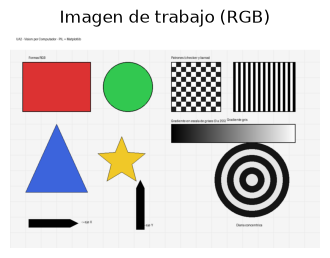

Tamaño: (1000, 700) | Modo: RGB


In [13]:

from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt

# Utilidad: mostrar imagen con título
def show(img, title=""):
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Intentar cargar imagen del disco
IMG_PATH = "UA2_vision_example.png"
try:
    img = Image.open(IMG_PATH).convert("RGB")
except FileNotFoundError:
    # Crear una imagen de prueba (degradado + patrón)
    h, w = 320, 480
    y = np.linspace(0, 255, h, dtype=np.uint8)[:, None]
    x = np.linspace(0, 255, w, dtype=np.uint8)[None, :]
    grad = np.stack([x.repeat(h,0), y.repeat(w,1), 255 - x], axis=-1)

    # Cuadriculado
    checker = ((np.indices((h,w)).sum(axis=0) // 16) % 2) * 80
    checker = np.stack([checker, np.zeros_like(checker), checker], axis=-1).astype(np.uint8)
    h, w = 320, 480
    arr = np.clip(grad.astype(np.int16) + checker.astype(np.int16), 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode="RGB")

# Convertir a NumPy
arr = np.array(img_rgb)
h, w = 320, 480
img_rgb = img.copy()
img_gray = img.convert("L")  # escala de grises (1 canal)

show(img_rgb, "Imagen de trabajo (RGB)")
print("Tamaño:", img_rgb.size, "| Modo:", img_rgb.mode)



## 1) Transformaciones con **NumPy** (sin funciones de alto nivel)

Usaremos **slicing** y utilidades básicas:
- **Flip horizontal**: `arr[:, ::-1]`
- **Flip vertical**: `arr[::-1, :]`
- **Rotación 90°**: `np.rot90(arr)`
- **Recorte** (*crop*): `arr[y0:y1, x0:x1]`


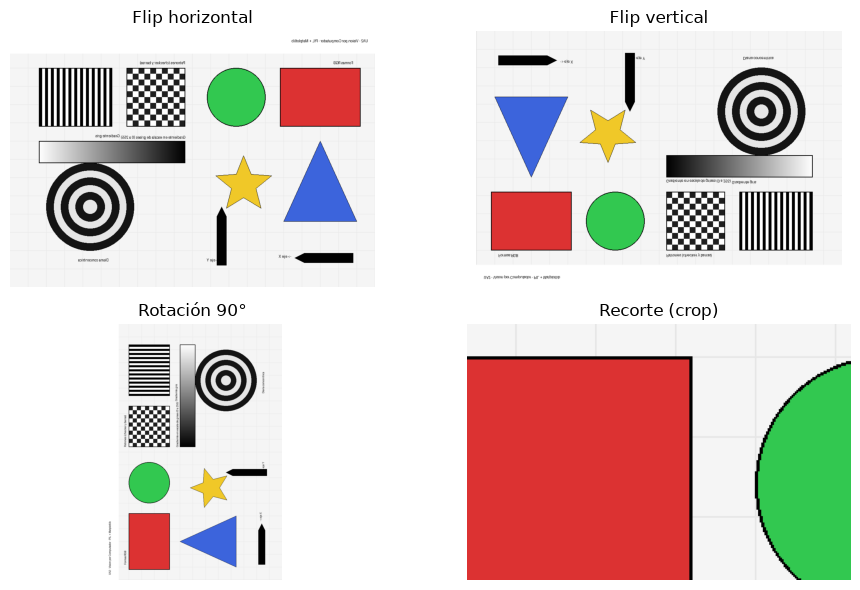

In [14]:

# Copias transformadas
flip_h = arr[:, ::-1]
flip_v = arr[::-1, :]
rot_90 = np.rot90(arr)  # antihorario
# Recorte central
cy, cx = h//2, w//2
crop = arr[cy-80:cy+80, cx-120:cx+120]

# Mostrar
plt.figure(figsize=(10,6))
plt.subplot(2,2,1); plt.imshow(flip_h); plt.title("Flip horizontal"); plt.axis("off")
plt.subplot(2,2,2); plt.imshow(flip_v); plt.title("Flip vertical"); plt.axis("off")
plt.subplot(2,2,3); plt.imshow(rot_90); plt.title("Rotación 90°"); plt.axis("off")
plt.subplot(2,2,4); plt.imshow(crop); plt.title("Recorte (crop)"); plt.axis("off")
plt.tight_layout(); plt.show()



## 2) Operaciones **pixel a pixel** (vectorizadas)

- **Negativo**: `255 - arr`  
- **Brillo**: sumar/restar un valor y **recortar** con `np.clip`  
- **Contraste** (simple): escalar alrededor de 128  
- **Resaltar canal**: trabajar sobre `arr[:,:,canal]`


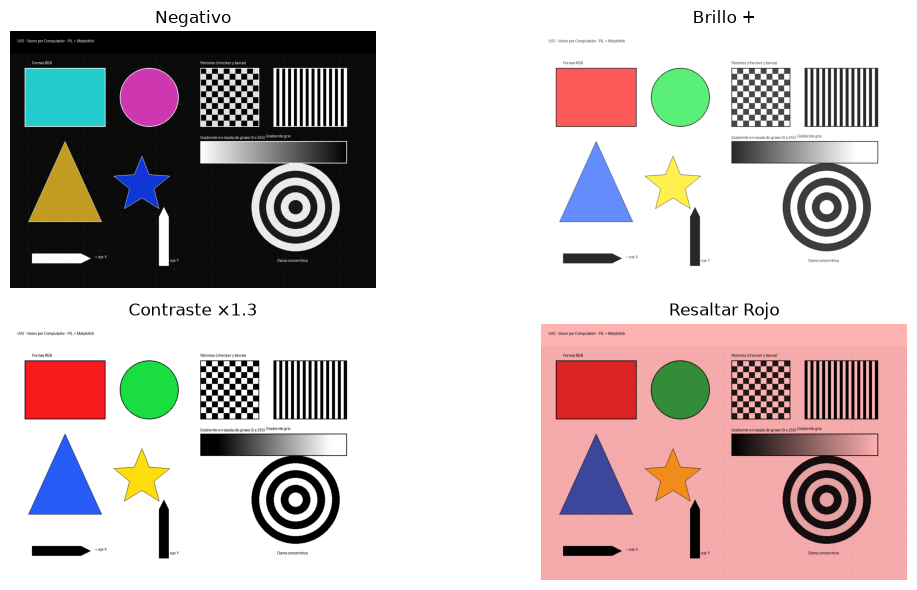

In [15]:

# Negativo
neg = 255 - arr

# Brillo (+40)
bright = np.clip(arr.astype(np.int16) + 40, 0, 255).astype(np.uint8)

# Contraste simple (factor >1 aumenta, <1 reduce) respecto a 128
factor = 1.3
contrast = np.clip((arr.astype(np.int16) - 128) * factor + 128, 0, 255).astype(np.uint8)

# Resaltar el canal rojo y atenuar otros
red_boost = arr.copy()
red_boost[:,:,1] = (red_boost[:,:,1] * 0.7).astype(np.uint8)
red_boost[:,:,2] = (red_boost[:,:,2] * 0.7).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(neg); plt.title("Negativo"); plt.axis("off")
plt.subplot(2,2,2); plt.imshow(bright); plt.title("Brillo +"); plt.axis("off")
plt.subplot(2,2,3); plt.imshow(contrast); plt.title("Contraste ×1.3"); plt.axis("off")
plt.subplot(2,2,4); plt.imshow(red_boost); plt.title("Resaltar Rojo"); plt.axis("off")
plt.tight_layout(); plt.show()



## 3) Filtros con **convolución** hecha a mano

Implementamos una función `convolve2d_rgb` que aplica un **kernel 2D** a cada canal.  
Ejemplos de kernels:
- **Blur (promedio 3×3)**  
- **Bordes (Laplaciano 3×3)**  
- **Sharpen** (nitidez)


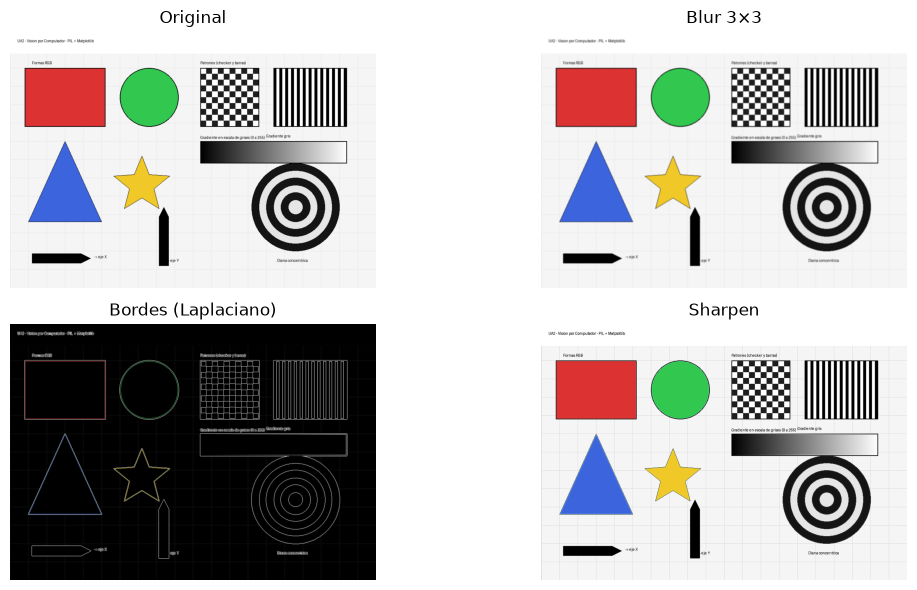

In [16]:

def convolve2d_gray(img_gray_arr, kernel):
    kh, kw = kernel.shape
    pad_y, pad_x = kh//2, kw//2
    # padding por reflejo para cuidar bordes
    padded = np.pad(img_gray_arr, ((pad_y, pad_y), (pad_x, pad_x)), mode="reflect").astype(np.float32)
    out = np.zeros_like(img_gray_arr, dtype=np.float32)
    for y in range(img_gray_arr.shape[0]):
        for x in range(img_gray_arr.shape[1]):
            region = padded[y:y+kh, x:x+kw]
            out[y,x] = np.sum(region * kernel)
    return np.clip(out, 0, 255).astype(np.uint8)

def convolve2d_rgb(img_rgb_arr, kernel):
    channels = []
    for c in range(3):
        channels.append(convolve2d_gray(img_rgb_arr[:,:,c], kernel))
    return np.stack(channels, axis=-1)

# Kernels
blur3 = np.ones((3,3), dtype=np.float32) / 9.0 
# np.array([[1, 2,  1],
#                     [2, 4, 2],
#                     [1, 2,  1]], dtype=np.float32) /16.0 KERNEL GAUSSIANO 3x3
laplace = np.array([[0, -1,  0],
                    [-1, 4, -1],
                    [0, -1,  0]], dtype=np.float32)
sharpen = np.array([[0, -1,  0],
                    [-1, 5, -1],
                    [0, -1,  0]], dtype=np.float32)

arr_blur = convolve2d_rgb(arr, blur3)
arr_edges = convolve2d_rgb(arr, laplace)
arr_sharp = convolve2d_rgb(arr, sharpen)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(arr); plt.title("Original"); plt.axis("off")
plt.subplot(2,2,2); plt.imshow(arr_blur); plt.title("Blur 3×3"); plt.axis("off")
plt.subplot(2,2,3); plt.imshow(arr_edges, cmap="gray"); plt.title("Bordes (Laplaciano)"); plt.axis("off")
plt.subplot(2,2,4); plt.imshow(arr_sharp); plt.title("Sharpen"); plt.axis("off")
plt.tight_layout(); plt.show()



## 4) Máscaras y composición

Creamos una **máscara circular** para mezclar dos versiones de la imagen (original y desenfocada).  
La máscara define **qué parte** de cada imagen se ve.


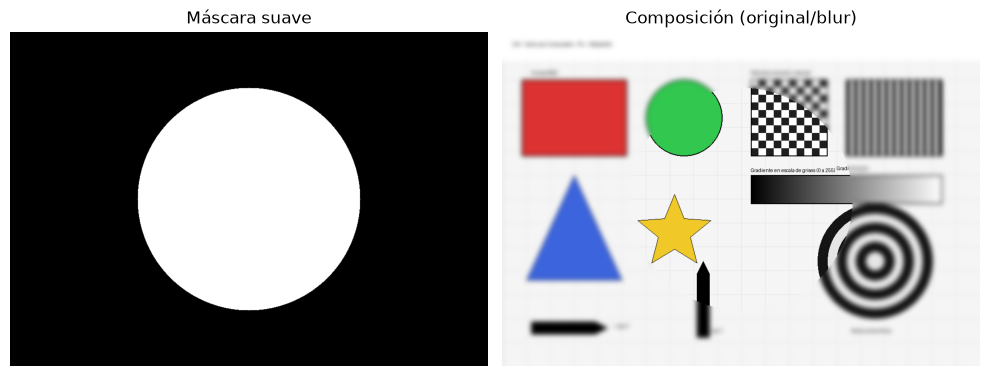

In [18]:

# Versión desenfocada con PIL
img_blur_pil = Image.fromarray(arr).filter(ImageFilter.GaussianBlur(radius=5))
arr_blur_soft = np.array(img_blur_pil)

# Use the real image size
arr = np.array(img)
h, w = arr.shape[:2]

# Máscara circular suave (0..1)
Y, X = np.ogrid[:h, :w]
cy, cx = h//2, w//2
radius = min(h, w) // 3
mask_circle = ((X - cx)**2 + (Y - cy)**2) <= radius**2
mask_circle = mask_circle.astype(np.float32)

# Borde suave (feather) con distancia al círculo
dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
feather = np.clip((radius - dist) / 20.0, 0, 1)  # 20 px de suavizado
mask_soft = np.clip(mask_circle + feather, 0, 1).astype(np.float32)

# Composición: dentro del círculo original, fuera blur (o al revés)
comp = (arr * mask_soft[...,None] + arr_blur_soft * (1 - mask_soft[...,None])).astype(np.uint8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(mask_soft, cmap="gray"); plt.title("Máscara suave"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(comp); plt.title("Composición (original/blur)"); plt.axis("off")
plt.tight_layout(); plt.show()



## Mini-reto (para clase o casa)
1. Crea un efecto **pixelado** usando slicing o `reshape` inteligente.  
2. Implementa un filtro **Sobel** (derivadas en X e Y) y muestra la magnitud.  
3. Compón dos imágenes (o dos versiones) usando una **máscara rectangular** diagonal.

> Pista: todo se puede hacer con NumPy puro (y un poco de PIL para cargar/guardar).


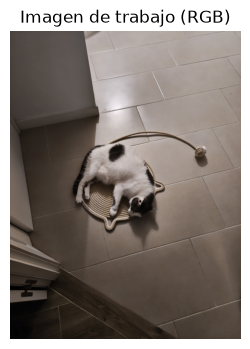

Tamaño: (1466, 1955)
Modo: RGB
Array: (1955, 1466, 3)
Alto: 1955 | Ancho: 1466


In [21]:
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt

def show(img, title=""):
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Tu imagen
IMG_PATH = 'Gatto.Jpg'  # cambia por 'UA2_landscape_example.jpg' o tus archivos
img = Image.open(IMG_PATH).convert('RGB')

# Convertir a NumPy
arr = np.array(img)

# Obtener alto y ancho
h, w = arr.shape[:2]

# Versiones RGB y gris
img_rgb = img.copy()
img_gray = img.convert("L")

show(img_rgb, "Imagen de trabajo (RGB)")

print("Tamaño:", img_rgb.size)
print("Modo:", img_rgb.mode)
print("Array:", arr.shape)
print("Alto:", h, "| Ancho:", w)

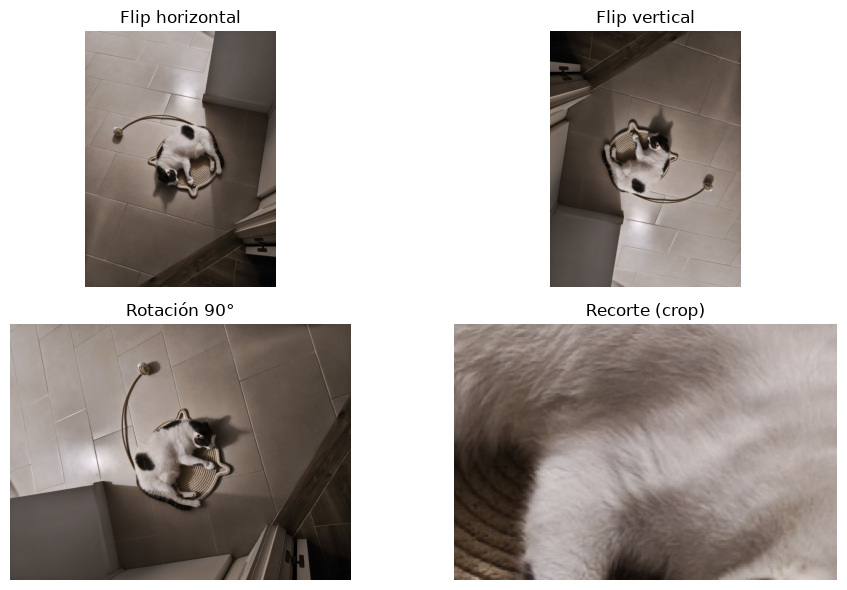

In [22]:
# Transformaciones con NumPy

flip_h = arr[:, ::-1]
flip_v = arr[::-1, :]
rot_90 = np.rot90(arr)  # antihorario

# Recorte central
cy, cx = h//2, w//2
crop = arr[cy-80:cy+80, cx-120:cx+120]

# Mostrar resultados
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(flip_h)
plt.title("Flip horizontal")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(flip_v)
plt.title("Flip vertical")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(rot_90)
plt.title("Rotación 90°")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(crop)
plt.title("Recorte (crop)")
plt.axis("off")

plt.tight_layout()
plt.show()

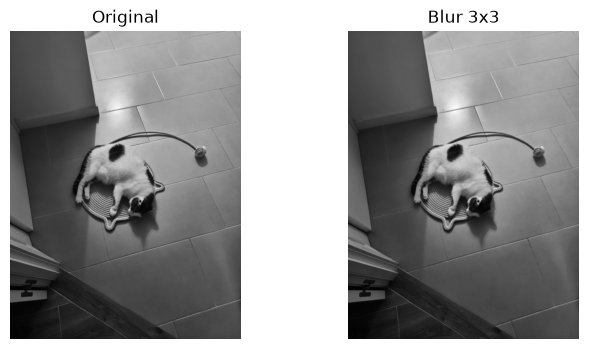

In [25]:
# Crear versión en escala de grises
img_gray = img.convert("L")

# Pasarla a NumPy
gray = np.array(img_gray, dtype=np.float32)

# Kernel blur 3x3
kernel_blur = np.ones((3,3), dtype=np.float32) / 9
def convolve2d(img, kernel):
    return convolve2d_gray(img, kernel)
# Aplicar convolución
blur = convolve2d(gray, kernel_blur)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Blur 3x3")
plt.axis("off")

plt.show()

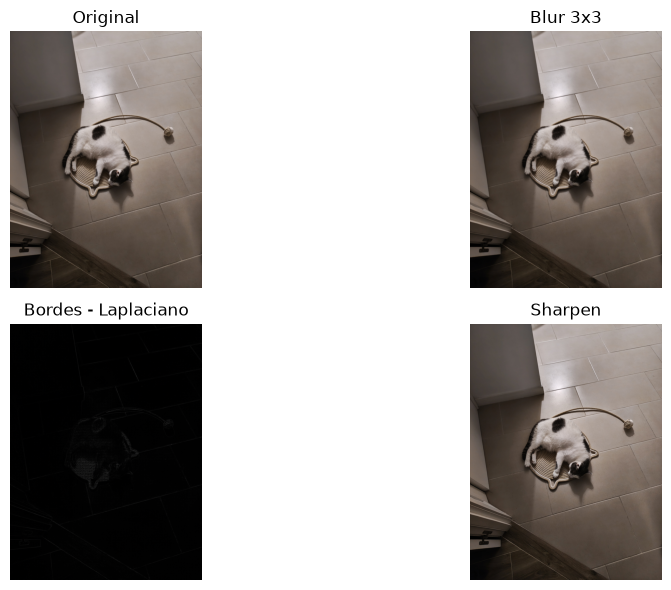

In [26]:
def convolve2d_gray(img_gray_arr, kernel):
    kh, kw = kernel.shape
    pad_y, pad_x = kh//2, kw//2

    padded = np.pad(
        img_gray_arr,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode="reflect"
    ).astype(np.float32)

    out = np.zeros_like(img_gray_arr, dtype=np.float32)

    for y in range(img_gray_arr.shape[0]):
        for x in range(img_gray_arr.shape[1]):
            region = padded[y:y+kh, x:x+kw]
            out[y, x] = np.sum(region * kernel)

    return np.clip(out, 0, 255).astype(np.uint8)


def convolve2d_rgb(img_rgb_arr, kernel):
    channels = []

    for c in range(3):
        channels.append(
            convolve2d_gray(img_rgb_arr[:, :, c], kernel)
        )

    return np.stack(channels, axis=-1)


# Kernel de desenfoque
blur3 = np.ones((3,3), dtype=np.float32) / 9.0

# Kernel Laplaciano - bordes
laplace = np.array([
    [0, -1,  0],
    [-1, 4, -1],
    [0, -1,  0]
], dtype=np.float32)

# Kernel Sharpen - nitidez
sharpen = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)


arr_blur = convolve2d_rgb(arr, blur3)
arr_edges = convolve2d_rgb(arr, laplace)
arr_sharp = convolve2d_rgb(arr, sharpen)


plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(arr)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(arr_blur)
plt.title("Blur 3x3")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(arr_edges)
plt.title("Bordes - Laplaciano")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(arr_sharp)
plt.title("Sharpen")
plt.axis("off")

plt.tight_layout()
plt.show()

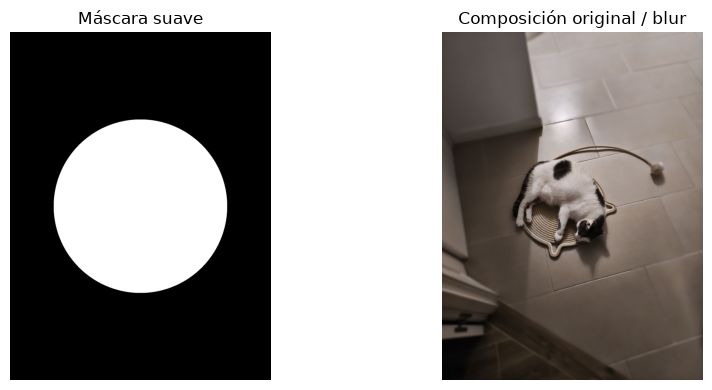

In [27]:
# Versión desenfocada con PIL
img_blur_pil = Image.fromarray(arr).filter(
    ImageFilter.GaussianBlur(radius=5)
)
arr_blur_soft = np.array(img_blur_pil)

# Máscara circular
Y, X = np.ogrid[:h, :w]

cy, cx = h//2, w//2
radius = min(h, w) // 3

mask_circle = ((X - cx)**2 + (Y - cy)**2) <= radius**2
mask_circle = mask_circle.astype(np.float32)

# Suavizar el borde de la máscara
dist = np.sqrt((X - cx)**2 + (Y - cy)**2)

feather = np.clip(
    (radius - dist) / 20.0,
    0,
    1
)

mask_soft = np.clip(
    mask_circle + feather,
    0,
    1
).astype(np.float32)

# Composición:
# dentro del círculo → imagen original
# fuera → imagen desenfocada
comp = (
    arr * mask_soft[..., None]
    + arr_blur_soft * (1 - mask_soft[..., None])
).astype(np.uint8)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_soft, cmap="gray")
plt.title("Máscara suave")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(comp)
plt.title("Composición original / blur")
plt.axis("off")

plt.tight_layout()
plt.show()

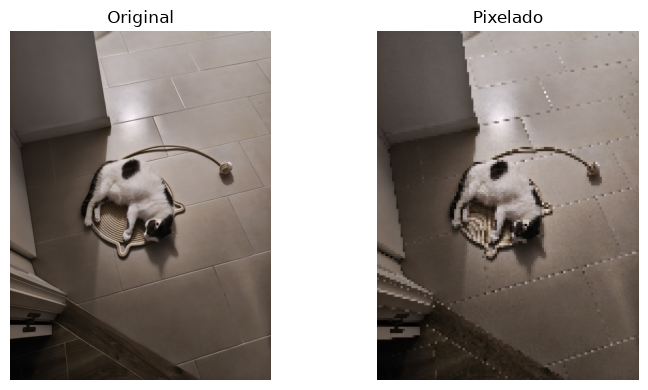

In [28]:
# MINI-RETO 1 — Efecto pixelado con NumPy

block = 12

# Tomamos un píxel cada 12
small = arr[::block, ::block]

# Volvemos a ampliar repitiendo los píxeles
pixelado = np.repeat(small, block, axis=0)
pixelado = np.repeat(pixelado, block, axis=1)

# Ajustar al tamaño original
pixelado = pixelado[:h, :w]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(arr)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pixelado)
plt.title("Pixelado")
plt.axis("off")

plt.tight_layout()
plt.show()

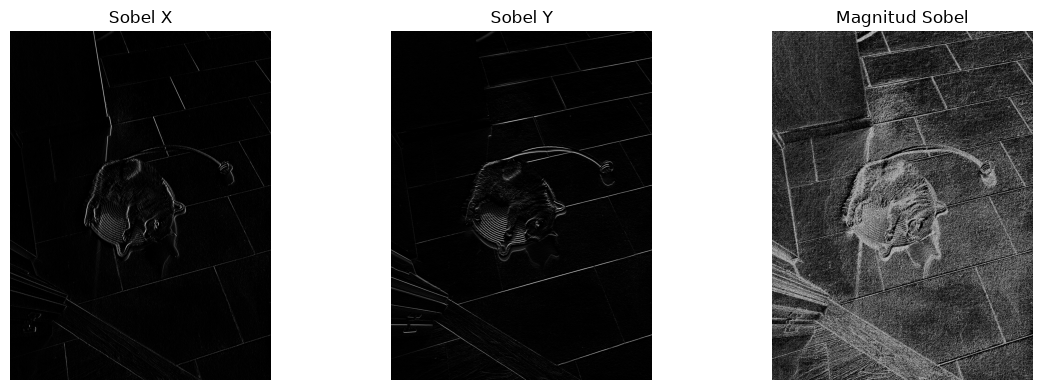

In [29]:
# MINI-RETO 2 — Sobel X, Sobel Y y magnitud

sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

sobel_x = convolve2d(gray, sobel_x_kernel)
sobel_y = convolve2d(gray, sobel_y_kernel)

# Magnitud total del gradiente
magnitud = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalizar para mostrar
magnitud = np.clip(magnitud, 0, 255)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(magnitud, cmap="gray")
plt.title("Magnitud Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()

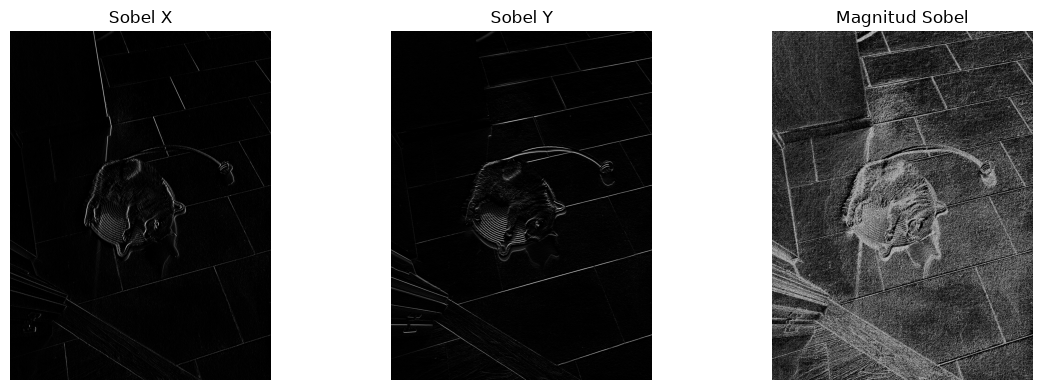

In [30]:
# MINI-RETO 2 — Sobel X, Sobel Y y magnitud

sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

sobel_x = convolve2d(gray, sobel_x_kernel)
sobel_y = convolve2d(gray, sobel_y_kernel)

# Magnitud total del gradiente
magnitud = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalizar para mostrar
magnitud = np.clip(magnitud, 0, 255)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(magnitud, cmap="gray")
plt.title("Magnitud Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()

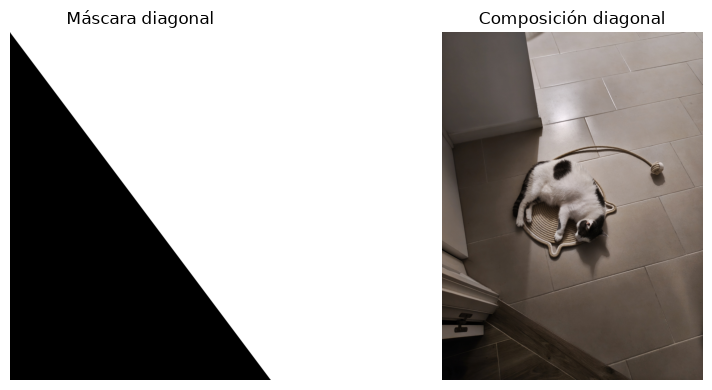

In [31]:
# MINI-RETO 3 — Composición con máscara diagonal

# Dos versiones de la imagen
img_a = arr
img_b = arr_blur

# Crear coordenadas
Y, X = np.ogrid[:h, :w]

# Máscara diagonal
mask_diag = X > (w / h) * Y

# Expandir máscara para 3 canales
mask_diag_3 = mask_diag[:, :, None]

# Combinar ambas imágenes
combinada = np.where(mask_diag_3, img_a, img_b)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mask_diag, cmap="gray")
plt.title("Máscara diagonal")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(combinada)
plt.title("Composición diagonal")
plt.axis("off")

plt.tight_layout()
plt.show()